Import Library and Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
# Standard split - don't change this
X_test = X[-10000:] # Last 10,000 for testing
y_test = y[-10000:]
X_train = X[:-10000] # First 60,000 for training
y_train = y[:-10000]
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

1. Data Exploration

## Dataset Basics

Training set size: 60000 examples, each with 784 features (pixels).
Test set size: 10000 examples, each with 784 features (pixels).

## Figure 1: Example Images of Digits


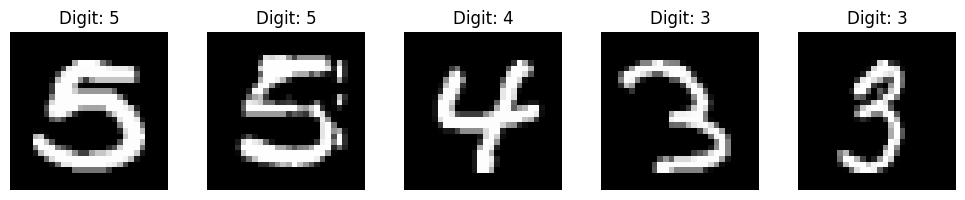


## Digit Distribution in Training Set
Number of examples per digit:
class
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

Most common digit: 1 (appears 6742 times)
Least common digit: 5 (appears 5421 times)


In [ ]:
# Describe dataset basics
print("## Dataset Basics")
print(f"\nTraining set size: {X_train.shape[0]} examples, each with {X_train.shape[1]} features (pixels).")
print(f"Test set size: {X_test.shape[0]} examples, each with {X_test.shape[1]} features (pixels).")

# Visualize example images of digits (1x5 grid)
print("\n## Figure 1: Example Images of Digits")
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    # Select a random index
    idx = np.random.randint(0, len(X_train))
    # Reshape the 784-pixel vector to a 28x28 image
    image = X_train.iloc[idx].values.reshape(28, 28)
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Digit: {y_train.iloc[idx]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Check if some digits appear more often than others.
print("\n## Digit Distribution in Training Set")
digit_counts = y_train.value_counts().sort_index()
print("Number of examples per digit:")
print(digit_counts)

most_common_digit = digit_counts.idxmax()
least_common_digit = digit_counts.idxmin()
print(f"\nMost common digit: {most_common_digit} (appears {digit_counts.max()} times)")
print(f"Least common digit: {least_common_digit} (appears {digit_counts.min()} times)")

2. Classic Classification Methods

In [ ]:
# Create a logistic regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model on training data
logreg.fit(X_train, y_train)
print("Model trained! ✓")
print(f"Number of coefficients: {len(logreg.coef_[0])}")

# Calculate accuracy
logreg_accuracy = logreg.score(X_test, y_test)
print(f"Logistic Regression Accuracy: {logreg_accuracy:.3f}")


Model trained! ✓
Number of coefficients: 784
Logistic Regression Accuracy: 0.926


In [ ]:
# Define the parameter grid for max_depth
param_grid = {'max_depth': [5, 10, 15, 20, 25, 30]}

# Instantiate a Decision Tree Classifier with random_state=42
dt_classifier = DecisionTreeClassifier(random_state=42)

# Create a GridSearchCV object for 5-fold cross-validation
print("Performing 5-fold cross-validation for Decision Tree (max_depth)...\n")
grid_search = GridSearchCV(dt_classifier, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best max_depth found
best_max_depth = grid_search.best_params_['max_depth']
print(f"Best max_depth found by cross-validation: {best_max_depth}")

# Retrieve the best estimator (Decision Tree model with optimal max_depth)
best_dt_model = grid_search.best_estimator_

# Predict on the test set using the best model
y_pred_dt = best_dt_model.predict(X_test)

# Print training and test accuracy of trees
train_acc = best_dt_model.score(X_train, y_train)
test_acc = best_dt_model.score(X_test, y_test)
print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")



Performing 5-fold cross-validation for Decision Tree (max_depth)...



In [ ]:
# Create a decision tree with maximum depth of 16
clf_16 = DecisionTreeClassifier(max_depth=16, random_state=42)
# Train the tree
clf_16.fit(X_train, y_train)
# Make predictions
y_pred = clf_16.predict(X_test)
# Calculate accuracy
train_acc = clf_16.score(X_train, y_train)
test_acc = clf_16.score(X_test, y_test)
print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

# Create a decision tree with maximum depth of 17
clf_17 = DecisionTreeClassifier(max_depth=17, random_state=42)
# Train the tree
clf_17.fit(X_train, y_train)
# Make predictions
y_pred = clf_17.predict(X_test)
# Calculate accuracy
train_acc = clf_17.score(X_train, y_train)
test_acc = clf_17.score(X_test, y_test)
print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Training accuracy: 0.988
Test accuracy: 0.883
Training accuracy: 0.991
Test accuracy: 0.880


In [ ]:
# Create an LDA model that projects to 2 dimensions
lda = LinearDiscriminantAnalysis(n_components=2)

# Train the model
lda.fit(X_train, y_train)

# Make predictions on test set
y_pred = lda.predict(X_test)

# Calculate accuracy
accuracy = lda.score(X_test, y_test)
print(f"LDA Test Accuracy: {accuracy:.3f}")

LDA Test Accuracy: 0.873


In [ ]:
# Create QDA model with default parameters
qda = QuadraticDiscriminantAnalysis()

# Fit the QDA model to the training data
qda.fit(X_train, y_train)

# Predict on the test set
y_pred_qda = qda.predict(X_test)

# Calculate and print the accuracy
accuracy_qda = accuracy_score(y_test, y_pred_qda)
print(f"QDA Test Accuracy: {accuracy_qda}")


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

QDA Test Accuracy: 0.5419


In [ ]:
# Create QDA model with parameters
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)

# Fit the QDA model to the training data
qda.fit(X_train, y_train)

# Predict on the test set
y_pred_qda = qda.predict(X_test)

# Calculate and print the accuracy
accuracy_qda = accuracy_score(y_test, y_pred_qda)
print(f"QDA Test Accuracy (param=): {accuracy_qda}")

QDA Test Accuracy (param=): 0.957


In [ ]:
# Define a range of regularization parameters to test
reg_params = np.linspace(0.0, 1.0, 21)  # From 0.0 to 1.0 with 21 steps

best_accuracy = -1
best_reg_param = None

print("Testing QDA with different regularization parameters...")
for reg_param in reg_params:
    qda = QuadraticDiscriminantAnalysis(reg_param=reg_param)
    qda.fit(X_train, y_train)
    y_pred_qda = qda.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_qda)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_reg_param = reg_param
    print(f"  Regularization Parameter: {reg_param:.2f}, Accuracy: {accuracy:.4f}")

print(f"\nBest Regularization Parameter: {best_reg_param:.2f}")
print(f"Highest Accuracy Achieved: {best_accuracy:.4f}")

Testing QDA with different regularization parameters...


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

  Regularization Parameter: 0.00, Accuracy: 0.5419
  Regularization Parameter: 0.05, Accuracy: 0.9577
  Regularization Parameter: 0.10, Accuracy: 0.9570
  Regularization Parameter: 0.15, Accuracy: 0.9539
  Regularization Parameter: 0.20, Accuracy: 0.9523
  Regularization Parameter: 0.25, Accuracy: 0.9491
  Regularization Parameter: 0.30, Accuracy: 0.9463
  Regularization Parameter: 0.35, Accuracy: 0.9449
  Regularization Parameter: 0.40, Accuracy: 0.9422
  Regularization Parameter: 0.45, Accuracy: 0.9391
  Regularization Parameter: 0.50, Accuracy: 0.9361
  Regularization Parameter: 0.55, Accuracy: 0.9333
  Regularization Parameter: 0.60, Accuracy: 0.9305
  Regularization Parameter: 0.65, Accuracy: 0.9279
  Regularization Parameter: 0.70, Accuracy: 0.9240
  Regularization Parameter: 0.75, Accuracy: 0.9202
  Regularization Parameter: 0.80, Accuracy: 0.9125
  Regularization Parameter: 0.85, Accuracy: 0.9031
  Regularization Parameter: 0.90, Accuracy: 0.8875
  Regularization Parameter: 0.9

In [ ]:
# Define a range of regularization parameters to test
reg_params = np.linspace(0.05, 0.1, 6)  # From 0.05 to 0.1 with 6 steps

best_accuracy = -1
best_reg_param = None

print("Testing QDA with different regularization parameters...")
for reg_param in reg_params:
    qda = QuadraticDiscriminantAnalysis(reg_param=reg_param)
    qda.fit(X_train, y_train)
    y_pred_qda = qda.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_qda)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_reg_param = reg_param
    print(f"  Regularization Parameter: {reg_param:.2f}, Accuracy: {accuracy:.4f}")

print(f"\nBest Regularization Parameter: {best_reg_param:.2f}")
print(f"Highest Accuracy Achieved: {best_accuracy:.4f}")

Testing QDA with different regularization parameters...
  Regularization Parameter: 0.05, Accuracy: 0.9577
  Regularization Parameter: 0.06, Accuracy: 0.9580
  Regularization Parameter: 0.07, Accuracy: 0.9575
  Regularization Parameter: 0.08, Accuracy: 0.9573
  Regularization Parameter: 0.09, Accuracy: 0.9567
  Regularization Parameter: 0.10, Accuracy: 0.9570

Best Regularization Parameter: 0.06
Highest Accuracy Achieved: 0.9580


In [ ]:
import time
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score

results = {}

# Logistic Regression
print("Evaluating Logistic Regression")
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
t0 = time.time()
logreg_model.fit(X_train, y_train)
t1 = time.time()
training_time_logreg = t1 - t0

y_pred_logreg = logreg_model.predict(X_test)
test_accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
macro_f1_logreg = f1_score(y_test, y_pred_logreg, average='macro')

results['Logistic Regression'] = {
    'Test Accuracy': test_accuracy_logreg,
    'Macro F1 Score': macro_f1_logreg,
    'Training Time (s)': training_time_logreg
}

# Decision Tree
print("Evaluating Decision Tree")
dt_model = DecisionTreeClassifier(max_depth=16, random_state=42)
t0 = time.time()
dt_model.fit(X_train, y_train)
t1 = time.time()
training_time_dt = t1 - t0

y_pred_dt = dt_model.predict(X_test)
test_accuracy_dt = accuracy_score(y_test, y_pred_dt)
macro_f1_dt = f1_score(y_test, y_pred_dt, average='macro')

results['Decision Tree'] = {
    'Test Accuracy': test_accuracy_dt,
    'Macro F1 Score': macro_f1_dt,
    'Training Time (s)': training_time_dt
}

# QDA
print("Evaluating QDA (reg_param=0.06)...")
qda_model = QuadraticDiscriminantAnalysis(reg_param=0.06)
t0 = time.time()
qda_model.fit(X_train, y_train)
t1 = time.time()
training_time_qda = t1 - t0

y_pred_qda = qda_model.predict(X_test)
test_accuracy_qda = accuracy_score(y_test, y_pred_qda)
macro_f1_qda = f1_score(y_test, y_pred_qda, average='macro')

results['QDA'] = {
    'Test Accuracy': test_accuracy_qda,
    'Macro F1 Score': macro_f1_qda,
    'Training Time (s)': training_time_qda
}

# Create and display the comparison table
comparison_df = pd.DataFrame.from_dict(results, orient='index')
display(comparison_df.round(4))




Evaluating Logistic Regression...
Evaluating Decision Tree (max_depth=16)...
Evaluating QDA (reg_param=0.06)...


,Test Accuracy,Macro F1 Score,Training Time (s)
Logistic Regression,0.9259,0.9248,116.8353
Decision Tree,0.8833,0.8815,16.9778
QDA,0.9580,0.9579,17.0833


Confusion Matrix for QDA (reg_param=0.06):


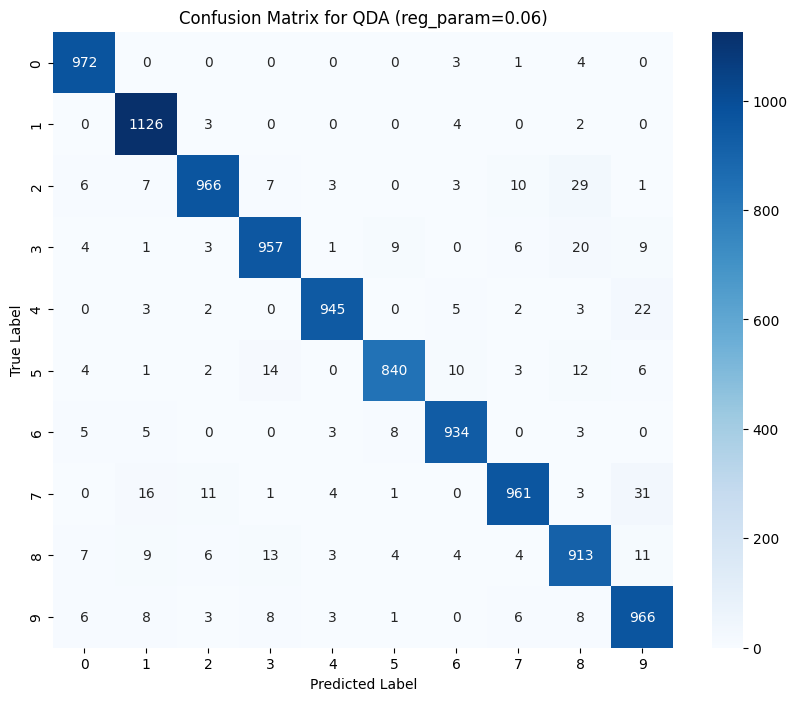


A confusion matrix is a table that is often used to describe the performance of a classification model (or 'classifier') on a set of test data for which the true values are known. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.
For example, the cell at row 'X' and column 'Y' indicates how many times a digit 'X' was incorrectly predicted as 'Y'. The diagonal elements represent the number of correctly classified instances.


<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Re-initialize and train the QDA
qda_model_006 = QuadraticDiscriminantAnalysis(reg_param=0.06)
qda_model_006.fit(X_train, y_train)

# Make predictions on the test set
y_pred_qda_006 = qda_model_006.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_qda_006)

print("Confusion Matrix for QDA (reg_param=0.06):")
# Display the confusion matrix using seaborn for better visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for QDA (reg_param=0.06)')
plt.show()
plt.savefig('figure2.jpeg')

print("\nA confusion matrix is a table that is often used to describe the performance of a classification model (or 'classifier') on a set of test data for which the true values are known. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.")
print("For example, the cell at row 'X' and column 'Y' indicates how many times a digit 'X' was incorrectly predicted as 'Y'. The diagonal elements represent the number of correctly classified instances.")

3. PCA

In [ ]:
# Create PCA for 2D projection
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train)
print(f"2D shape: {X_2d.shape}")
print(f"Variance captured by PC1: {pca_2d.explained_variance_ratio_[0]:.3f}")
print(f"Variance captured by PC2: {pca_2d.explained_variance_ratio_[1]:.3f}")
print(f"Total variance in 2D: {pca_2d.explained_variance_ratio_.sum():.3f}")

2D shape: (60000, 2)
Variance captured by PC1: 0.097
Variance captured by PC2: 0.071
Total variance in 2D: 0.168


In [ ]:
# Create PCA for 10 components
pca_10d = PCA(n_components=10)
# Fit pca_10d and transform X_train
X_10d = pca_10d.fit_transform(X_train)
print(f"10D shape: {X_10d.shape}")
print(f"Variance captured by PC1: {pca_10d.explained_variance_ratio_[0]:.3f}")
print(f"Variance captured by PC2: {pca_10d.explained_variance_ratio_[1]:.3f}")
print(f"Total variance in 10D: {pca_10d.explained_variance_ratio_.sum():.3f}")

10D shape: (60000, 10)
Variance captured by PC1: 0.097
Variance captured by PC2: 0.071
Total variance in 10D: 0.488


In [ ]:
# Create PCA for 50 components
pca_50d = PCA(n_components=50)
X_50d = pca_50d.fit_transform(X_train)
print(f"50D shape: {X_50d.shape}")
print(f"Variance captured by PC1: {pca_50d.explained_variance_ratio_[0]:.3f}")
print(f"Variance captured by PC2: {pca_50d.explained_variance_ratio_[1]:.3f}")
print(f"Total variance in 50D: {pca_50d.explained_variance_ratio_.sum():.3f}")

50D shape: (60000, 50)
Variance captured by PC1: 0.097
Variance captured by PC2: 0.071
Total variance in 50D: 0.825


In [ ]:
# Create PCA for 100 components
pca_100d = PCA(n_components=100)
X_100d = pca_100d.fit_transform(X_train)
print(f"100D shape: {X_100d.shape}")
print(f"Variance captured by PC1: {pca_100d.explained_variance_ratio_[0]:.3f}")
print(f"Variance captured by PC2: {pca_100d.explained_variance_ratio_[1]:.3f}")
print(f"Total variance in 100D: {pca_100d.explained_variance_ratio_.sum():.3f}")

100D shape: (60000, 100)
Variance captured by PC1: 0.097
Variance captured by PC2: 0.071
Total variance in 100D: 0.915


In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score
import time

# Apply PCA
# Using 10 components
pca = PCA(n_components=10, random_state=42)
print(f"Applying PCA with {pca.n_components} components...")

X_train_10pca = pca.fit_transform(X_train)
X_test_10pca = pca.transform(X_test)

print(f"Original training data shape: {X_train.shape}")
print(f"PCA-transformed training data shape: {X_train_10pca.shape}")
print(f"Total variance explained by {pca.n_components} components: {pca.explained_variance_ratio_.sum():.3f}")

# Train and Evaluate Logistic Regression with PCA
print("\nTraining Logistic Regression with PCA data...")
logreg_10pca = LogisticRegression(max_iter=1000, random_state=42)
t0_logreg_10pca = time.time()
logreg_10pca.fit(X_train_10pca, y_train)
t1_logreg_10pca = time.time()
accuracy_logreg_10pca = logreg_10pca.score(X_test_10pca, y_test)
y_pred_logreg_10pca = logreg_10pca.predict(X_test_10pca)
macro_f1_logreg_10pca = f1_score(y_test, y_pred_logreg_10pca, average='macro')
print(f"Logistic Regression (PCA) Test Accuracy: {accuracy_logreg_10pca:.4f}")
print(f"Logistic Regression (PCA) Macro F1 Score: {macro_f1_logreg_10pca:.4f}")
print(f"Logistic Regression (PCA) Training Time: {t1_logreg_10pca - t0_logreg_10pca:.2f}s")

# Train and Evaluate Decision Tree with PCA
print("\nTraining Decision Tree (max_depth=16) with PCA data...")
dt_10pca = DecisionTreeClassifier(max_depth=16, random_state=42)
t0_dt_10pca = time.time()
dt_10pca.fit(X_train_10pca, y_train)
t1_dt_10pca = time.time()
accuracy_dt_10pca = dt_10pca.score(X_test_10pca, y_test)
y_pred_dt_10pca = dt_10pca.predict(X_test_10pca)
macro_f1_dt_10pca = f1_score(y_test, y_pred_dt_10pca, average='macro')
print(f"Decision Tree (PCA) Test Accuracy: {accuracy_dt_10pca:.4f}")
print(f"Decision Tree (PCA) Macro F1 Score: {macro_f1_dt_10pca:.4f}")
print(f"Decision Tree (PCA) Training Time: {t1_dt_10pca - t0_dt_10pca:.2f}s")

# Train and Evaluate QDA with PCA
print("\nTraining QDA (reg_param=0.06) with PCA data...")
qda_10pca = QuadraticDiscriminantAnalysis(reg_param=0.06)
t0_qda_10pca = time.time()
qda_10pca.fit(X_train_10pca, y_train)
t1_qda_10pca = time.time()
accuracy_qda_10pca = qda_10pca.score(X_test_10pca, y_test)
y_pred_qda_10pca = qda_10pca.predict(X_test_10pca)
macro_f1_qda_10pca = f1_score(y_test, y_pred_qda_10pca, average='macro')
print(f"QDA (PCA) Test Accuracy: {accuracy_qda_10pca:.4f}")
print(f"QDA (PCA) Macro F1 Score: {macro_f1_qda_10pca:.4f}")
print(f"QDA (PCA) Training Time: {t1_qda_10pca - t0_qda_10pca:.2f}s")

Applying PCA with 10 components...
Original training data shape: (60000, 784)
PCA-transformed training data shape: (60000, 10)
Total variance explained by 10 components: 0.488

Training Logistic Regression with PCA data...
Logistic Regression (PCA) Test Accuracy: 0.8091
Logistic Regression (PCA) Macro F1 Score: 0.8057
Logistic Regression (PCA) Training Time: 3.16s

Training Decision Tree (max_depth=16) with PCA data...
Decision Tree (PCA) Test Accuracy: 0.8329
Decision Tree (PCA) Macro F1 Score: 0.8305
Decision Tree (PCA) Training Time: 1.85s

Training QDA (reg_param=0.06) with PCA data...
QDA (PCA) Test Accuracy: 0.8907
QDA (PCA) Macro F1 Score: 0.8892
QDA (PCA) Training Time: 0.08s


In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score
import time

# Apply PCA
# Using 50 components
pca = PCA(n_components=50, random_state=42)
print(f"Applying PCA with {pca.n_components} components...")

X_train_50pca = pca.fit_transform(X_train)
X_test_50pca = pca.transform(X_test)

print(f"Original training data shape: {X_train.shape}")
print(f"PCA-transformed training data shape: {X_train_50pca.shape}")
print(f"Total variance explained by {pca.n_components} components: {pca.explained_variance_ratio_.sum():.3f}")

# Train and Evaluate Logistic Regression with PCA
print("\nTraining Logistic Regression with PCA data...")
logreg_50pca = LogisticRegression(max_iter=1000, random_state=42)
t0_logreg_50pca = time.time()
logreg_50pca.fit(X_train_50pca, y_train)
t1_logreg_50pca = time.time()
accuracy_logreg_50pca = logreg_50pca.score(X_test_50pca, y_test)
y_pred_logreg_50pca = logreg_50pca.predict(X_test_50pca)
macro_f1_logreg_50pca = f1_score(y_test, y_pred_logreg_50pca, average='macro')
print(f"Logistic Regression (PCA) Test Accuracy: {accuracy_logreg_50pca:.4f}")
print(f"Logistic Regression (PCA) Macro F1 Score: {macro_f1_logreg_50pca:.4f}")
print(f"Logistic Regression (PCA) Training Time: {t1_logreg_50pca - t0_logreg_50pca:.2f}s")

# Train and Evaluate Decision Tree with PCA
print("\nTraining Decision Tree (max_depth=16) with PCA data...")
dt_50pca = DecisionTreeClassifier(max_depth=16, random_state=42)
t0_dt_50pca = time.time()
dt_50pca.fit(X_train_50pca, y_train)
t1_dt_50pca = time.time()
accuracy_dt_50pca = dt_50pca.score(X_test_50pca, y_test)
y_pred_dt_50pca = dt_50pca.predict(X_test_50pca)
macro_f1_dt_50pca = f1_score(y_test, y_pred_dt_50pca, average='macro')
print(f"Decision Tree (PCA) Test Accuracy: {accuracy_dt_50pca:.4f}")
print(f"Decision Tree (PCA) Macro F1 Score: {macro_f1_dt_50pca:.4f}")
print(f"Decision Tree (PCA) Training Time: {t1_dt_50pca - t0_dt_50pca:.2f}s")

# Train and Evaluate QDA with PCA
print("\nTraining QDA (reg_param=0.06) with PCA data...")
qda_50pca = QuadraticDiscriminantAnalysis(reg_param=0.06)
t0_qda_50pca = time.time()
qda_50pca.fit(X_train_50pca, y_train)
t1_qda_50pca = time.time()
accuracy_qda_50pca = qda_50pca.score(X_test_50pca, y_test)
y_pred_qda_50pca = qda_50pca.predict(X_test_50pca)
macro_f1_qda_50pca = f1_score(y_test, y_pred_qda_50pca, average='macro')
print(f"QDA (PCA) Test Accuracy: {accuracy_qda_50pca:.4f}")
print(f"QDA (PCA) Macro F1 Score: {macro_f1_qda_50pca:.4f}")
print(f"QDA (PCA) Training Time: {t1_qda_50pca - t0_qda_50pca:.2f}s")

Applying PCA with 50 components...
Original training data shape: (60000, 784)
PCA-transformed training data shape: (60000, 50)
Total variance explained by 50 components: 0.825

Training Logistic Regression with PCA data...
Logistic Regression (PCA) Test Accuracy: 0.9117
Logistic Regression (PCA) Macro F1 Score: 0.9103
Logistic Regression (PCA) Training Time: 7.71s

Training Decision Tree (max_depth=16) with PCA data...
Decision Tree (PCA) Test Accuracy: 0.8434
Decision Tree (PCA) Macro F1 Score: 0.8410
Decision Tree (PCA) Training Time: 8.94s

Training QDA (reg_param=0.06) with PCA data...
QDA (PCA) Test Accuracy: 0.9661
QDA (PCA) Macro F1 Score: 0.9659
QDA (PCA) Training Time: 0.28s


In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score
import time

# Apply PCA
# Using 100 components
pca = PCA(n_components=100, random_state=42)
print(f"Applying PCA with {pca.n_components} components...")

X_train_100pca = pca.fit_transform(X_train)
X_test_100pca = pca.transform(X_test)

print(f"Original training data shape: {X_train.shape}")
print(f"PCA-transformed training data shape: {X_train_100pca.shape}")
print(f"Total variance explained by {pca.n_components} components: {pca.explained_variance_ratio_.sum():.3f}")

# Train and Evaluate Logistic Regression with PCA
print("\nTraining Logistic Regression with PCA data...")
logreg_100pca = LogisticRegression(max_iter=1000, random_state=42)
t0_logreg_100pca = time.time()
logreg_100pca.fit(X_train_100pca, y_train)
t1_logreg_100pca = time.time()
accuracy_logreg_100pca = logreg_100pca.score(X_test_100pca, y_test)
y_pred_logreg_100pca = logreg_100pca.predict(X_test_100pca)
macro_f1_logreg_100pca = f1_score(y_test, y_pred_logreg_100pca, average='macro')
print(f"Logistic Regression (PCA) Test Accuracy: {accuracy_logreg_100pca:.4f}")
print(f"Logistic Regression (PCA) Macro F1 Score: {macro_f1_logreg_100pca:.4f}")
print(f"Logistic Regression (PCA) Training Time: {t1_logreg_100pca - t0_logreg_100pca:.2f}s")

# Train and Evaluate Decision Tree with PCA
print("\nTraining Decision Tree (max_depth=16) with PCA data...")
dt_100pca = DecisionTreeClassifier(max_depth=16, random_state=42)
t0_dt_100pca = time.time()
dt_100pca.fit(X_train_100pca, y_train)
t1_dt_100pca = time.time()
accuracy_dt_100pca = dt_100pca.score(X_test_100pca, y_test)
y_pred_dt_100pca = dt_100pca.predict(X_test_100pca)
macro_f1_dt_100pca = f1_score(y_test, y_pred_dt_100pca, average='macro')
print(f"Decision Tree (PCA) Test Accuracy: {accuracy_dt_100pca:.4f}")
print(f"Decision Tree (PCA) Macro F1 Score: {macro_f1_dt_100pca:.4f}")
print(f"Decision Tree (PCA) Training Time: {t1_dt_100pca - t0_dt_100pca:.2f}s")

#  Train and Evaluate QDA with PCA
print("\nTraining QDA (reg_param=0.06) with PCA data...")
qda_100pca = QuadraticDiscriminantAnalysis(reg_param=0.06)
t0_qda_100pca = time.time()
qda_100pca.fit(X_train_100pca, y_train)
t1_qda_100pca = time.time()
accuracy_qda_100pca = qda_100pca.score(X_test_100pca, y_test)
y_pred_qda_100pca = qda_100pca.predict(X_test_100pca)
macro_f1_qda_100pca = f1_score(y_test, y_pred_qda_100pca, average='macro')
print(f"QDA (PCA) Test Accuracy: {accuracy_qda_100pca:.4f}")
print(f"QDA (PCA) Macro F1 Score: {macro_f1_qda_100pca:.4f}")
print(f"QDA (PCA) Training Time: {t1_qda_100pca - t0_qda_100pca:.2f}s")

Applying PCA with 100 components...
Original training data shape: (60000, 784)
PCA-transformed training data shape: (60000, 100)
Total variance explained by 100 components: 0.915

Training Logistic Regression with PCA data...
Logistic Regression (PCA) Test Accuracy: 0.9218
Logistic Regression (PCA) Macro F1 Score: 0.9206
Logistic Regression (PCA) Training Time: 10.16s

Training Decision Tree (max_depth=16) with PCA data...
Decision Tree (PCA) Test Accuracy: 0.8401
Decision Tree (PCA) Macro F1 Score: 0.8377
Decision Tree (PCA) Training Time: 21.21s

Training QDA (reg_param=0.06) with PCA data...
QDA (PCA) Test Accuracy: 0.9645
QDA (PCA) Macro F1 Score: 0.9643
QDA (PCA) Training Time: 0.74s


In [ ]:
import pandas as pd
import numpy as np # For numpy functions if needed

# Initialize a dictionary to store all results
all_results = {}

# 10 PCA Components
all_results['Logistic Regression (10 PCA)'] = {
    'Test Accuracy': accuracy_logreg_10pca,
    'Macro F1 Score': macro_f1_logreg_10pca,
    'Training Time (s)': t1_logreg_10pca - t0_logreg_10pca
}
all_results['Decision Tree (10 PCA)'] = {
    'Test Accuracy': accuracy_dt_10pca,
    'Macro F1 Score': macro_f1_dt_10pca,
    'Training Time (s)': t1_dt_10pca - t0_dt_10pca
}
all_results['QDA (10 PCA)'] = {
    'Test Accuracy': accuracy_qda_10pca,
    'Macro F1 Score': macro_f1_qda_10pca,
    'Training Time (s)': t1_qda_10pca - t0_qda_10pca
}

# 50 PCA Components
all_results['Logistic Regression (50 PCA)'] = {
    'Test Accuracy': accuracy_logreg_50pca,
    'Macro F1 Score': macro_f1_logreg_50pca,
    'Training Time (s)': t1_logreg_50pca - t0_logreg_50pca
}
all_results['Decision Tree (50 PCA)'] = {
    'Test Accuracy': accuracy_dt_50pca,
    'Macro F1 Score': macro_f1_dt_50pca,
    'Training Time (s)': t1_dt_50pca - t0_dt_50pca
}
all_results['QDA (50 PCA)'] = {
    'Test Accuracy': accuracy_qda_50pca,
    'Macro F1 Score': macro_f1_qda_50pca,
    'Training Time (s)': t1_qda_50pca - t0_qda_50pca
}

# 100 PCA Components
all_results['Logistic Regression (100 PCA)'] = {
    'Test Accuracy': accuracy_logreg_100pca,
    'Macro F1 Score': macro_f1_logreg_100pca,
    'Training Time (s)': t1_logreg_100pca - t0_logreg_100pca
}
all_results['Decision Tree (100 PCA)'] = {
    'Test Accuracy': accuracy_dt_100pca,
    'Macro F1 Score': macro_f1_dt_100pca,
    'Training Time (s)': t1_dt_100pca - t0_dt_100pca
}
all_results['QDA (100 PCA)'] = {
    'Test Accuracy': accuracy_qda_100pca,
    'Macro F1 Score': macro_f1_qda_100pca,
    'Training Time (s)': t1_qda_100pca - t0_qda_100pca
}

# Create DataFrame
comparison_df_pca = pd.DataFrame.from_dict(all_results, orient='index')

    df_styles = pd.DataFrame('', index=df.index, columns=df.columns)

    for idx, row_label in enumerate(df.index):
        if '10 PCA' in row_label:
            df_styles.loc[row_label] = f'background-color: {colors["10 PCA"]}'
        elif '50 PCA' in row_label:
            df_styles.loc[row_label] = f'background-color: {colors["50 PCA"]}'
        elif '100 PCA' in row_label:
            df_styles.loc[row_label] = f'background-color: {colors["100 PCA"]}'
    return df_styles

# Apply the styling
styled_table = comparison_df_pca.round(4).style.apply(style_pca_groups, axis=None) \
    .background_gradient(cmap='Blues', subset=['Test Accuracy', 'Macro F1 Score'], axis=0) \
    .background_gradient(cmap='Blues_r', subset=['Training Time (s)'], axis=0) \
    .set_properties(**{'font-size': '10pt', 'border': '1px solid #ddd', 'text-align': 'center'}) \
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('font-weight', 'bold')]}]) \


display(styled_table)

,Test Accuracy,Macro F1 Score,Training Time (s)
Logistic Regression (10 PCA),0.809100,0.805700,4.480700
Decision Tree (10 PCA),0.832900,0.830500,2.647700
QDA (10 PCA),0.890700,0.889200,0.147500
Logistic Regression (50 PCA),0.911700,0.910300,5.263500
Decision Tree (50 PCA),0.843400,0.841000,10.563100
QDA (50 PCA),0.966100,0.965900,0.277600
Logistic Regression (100 PCA),0.921800,0.920600,10.162900
Decision Tree (100 PCA),0.840100,0.837700,21.211600
QDA (100 PCA),0.964500,0.964300,0.740300


4. Neural Network

In [ ]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam, SGD
from keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

# Load MNIST from Keras (same dataset, more reliable)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Flatten images from 28x28 to 784 features
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert labels to Integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [ ]:
# Base Neural Network

model1 = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
print("model created!")
model1.summary()

model1.compile(
    optimizer=Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("model compiled!")

history1 = model1.fit(
    X_train, y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)
print("model trained!")

test_loss, test_acc = model1.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


val_loss, val_acc = model1.evaluate(X_test, y_test)
print(f"\nValidation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

model created!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

model compiled!
model trained!
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9756 - loss: 0.0987

Test Accuracy: 0.9784 (97.84%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9756 - loss: 0.0987

Validation Accuracy: 0.9784 (97.84%)


In [ ]:
# Find Best Combo for 1 Hidden Layer

# Unit choices
units = [64, 96, 128, 160, 192, 224, 256]

# Generate all combinations
unit_combos = [(u1) for u1 in units]

best_combo = None
best_val_acc = -1
results = []

print("Testing all 7 one-layer models...\n")

for (u1) in unit_combos:

    # Build model
    model = Sequential([
        Dense(u1, activation='relu', input_shape=(784,)),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer=Adam(0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    # Get the best validation accuracy for this model
    val_acc = max(history.history['val_accuracy'])
    results.append((u1, val_acc))

    print(f"Units ({u1}) → Best Val Acc = {val_acc:.4f}")

      # Track best model overall
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_combo = (u1)

print("\n==============================================")
print(f"Best 1-Layer Model: {best_combo}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing all 7 one-layer models...



KeyboardInterrupt: 

In [ ]:
# Find best Digits Combo for 2 layer

units = [64, 96, 128, 160, 192, 224, 256]
unit_pairs = [(u1, u2) for u1 in units for u2 in units]
best_units = None
best_val = -1
results = []

print("Testing all 49 two-layer models...\n")

for u1, u2 in unit_pairs:
    model = Sequential([
        Dense(u1, activation='relu', input_shape=(784,)),
        Dense(u2, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer=Adam(0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=256,
        validation_split=0.2,
        verbose=0)

    val_acc = max(history.history['val_accuracy'])
    results.append((u1, u2, val_acc))

    print(f"Units ({u1}, {u2}) → Best Val Acc = {val_acc:.4f}")

    # Track best model overall
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_combo = (u1, u2)

print("\n==============================================")
print(f"Best 2-Layer Model: {best_combo}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

###### (256,224) = 0.9799

Testing all 49 two-layer models...

Units (64, 64) → Best Val Acc = 0.9698
Units (64, 96) → Best Val Acc = 0.9722
Units (64, 128) → Best Val Acc = 0.9736
Units (64, 160) → Best Val Acc = 0.9736
Units (64, 192) → Best Val Acc = 0.9743
Units (64, 224) → Best Val Acc = 0.9743
Units (64, 256) → Best Val Acc = 0.9726
Units (96, 64) → Best Val Acc = 0.9722
Units (96, 96) → Best Val Acc = 0.9755
Units (96, 128) → Best Val Acc = 0.9747
Units (96, 160) → Best Val Acc = 0.9752
Units (96, 192) → Best Val Acc = 0.9760
Units (96, 224) → Best Val Acc = 0.9757
Units (96, 256) → Best Val Acc = 0.9756
Units (128, 64) → Best Val Acc = 0.9761
Units (128, 96) → Best Val Acc = 0.9763
Units (128, 128) → Best Val Acc = 0.9751
Units (128, 160) → Best Val Acc = 0.9768
Units (128, 192) → Best Val Acc = 0.9753
Units (128, 224) → Best Val Acc = 0.9751
Units (128, 256) → Best Val Acc = 0.9778
Units (160, 64) → Best Val Acc = 0.9758
Units (160, 96) → Best Val Acc = 0.9782
Units (160, 128) → Best Val Acc = 0.9787
Un

In [ ]:
# Evaluate Combo

model2 = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

model2.compile(
    optimizer=Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("model compiled!")

history2 = model2.fit(
    X_train, y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)
print("model trained!")

val_loss, val_acc = model2.evaluate(X_test, y_test)
print(f"\nValidation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

In [ ]:
# Find Best Combo for 3 Hidden Layers

# Unit choices
units = [64, 96, 128, 160, 192, 224, 256]

# Generate all combinations
unit_combos_3 = [(u1, u2, u3) for u1 in units for u2 in units for u3 in units]

best_combo = None
best_val_acc = -1
results = []

print("Testing all 343 three-layer models...\n")

for (u1, u2, u3) in unit_combos_3:

    # Build model
    model = Sequential([
        Dense(u1, activation='relu', input_shape=(784,)),
        Dense(u2, activation='relu'),
        Dense(u3, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer=Adam(0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    # Get the best validation accuracy for this model
    val_acc = max(history.history['val_accuracy'])
    results.append((u1, u2, u3, val_acc))

    print(f"Units ({u1}, {u2}, {u3}) → Best Val Acc = {val_acc:.4f}")

      # Track best model overall
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_combo = (u1, u2, u3)

print("\n==============================================")
print(f"Best 3-Layer Model: {best_combo}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

##### (224,192,128) = 0.9803

Testing all 343 three-layer models...

Units (64, 64, 64) → Best Val Acc = 0.9725
Units (64, 64, 96) → Best Val Acc = 0.9722
Units (64, 64, 128) → Best Val Acc = 0.9712
Units (64, 64, 160) → Best Val Acc = 0.9736
Units (64, 64, 192) → Best Val Acc = 0.9712
Units (64, 64, 224) → Best Val Acc = 0.9720
Units (64, 64, 256) → Best Val Acc = 0.9732
Units (64, 96, 64) → Best Val Acc = 0.9728
Units (64, 96, 96) → Best Val Acc = 0.9721
Units (64, 96, 128) → Best Val Acc = 0.9737
Units (64, 96, 160) → Best Val Acc = 0.9720
Units (64, 96, 192) → Best Val Acc = 0.9747
Units (64, 96, 224) → Best Val Acc = 0.9731
Units (64, 96, 256) → Best Val Acc = 0.9725
Units (64, 128, 64) → Best Val Acc = 0.9738
Units (64, 128, 96) → Best Val Acc = 0.9740
Units (64, 128, 128) → Best Val Acc = 0.9740
Units (64, 128, 160) → Best Val Acc = 0.9724
Units (64, 128, 192) → Best Val Acc = 0.9738
Units (64, 128, 224) → Best Val Acc = 0.9728
Units (64, 128, 256) → Best Val Acc = 0.9758
Units (64, 160, 64) → Best Val Acc =

In [ ]:
#Find Best Combo of Activations (2L)

# Possible activations
activations = ['relu', 'tanh', 'sigmoid']

# Create all activation combinations for 2 layers
activation_combos = [(a1, a2)
                      for a1 in activations
                      for a2 in activations
                     ]

best_combo = None
best_val_acc = -1
results = []

print("Testing all 9 activation combinations for (256,128)...\n")

for act1, act2 in activation_combos:

    # Build model with different activations per layer
    model = Sequential([
        Dense(256, activation=act1, input_shape=(784,)),
        Dense(224, activation=act2),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    # Get max validation accuracy
    val_acc = max(history.history['val_accuracy'])
    results.append((act1, act2, val_acc))

    print(f"Activations ({act1}, {act2}) → Val Acc = {val_acc:.4f}")

    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_combo = (act1, act2)

print("\n==============================================")
print(f"Best Activation Combo: {best_combo}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing all 9 activation combinations for (224,192,128)...

Activations (relu, relu) → Val Acc = 0.9779
Activations (relu, tanh) → Val Acc = 0.9796
Activations (relu, sigmoid) → Val Acc = 0.9791
Activations (tanh, relu) → Val Acc = 0.9776
Activations (tanh, tanh) → Val Acc = 0.9771
Activations (tanh, sigmoid) → Val Acc = 0.9787
Activations (sigmoid, relu) → Val Acc = 0.9737
Activations (sigmoid, tanh) → Val Acc = 0.9751
Activations (sigmoid, sigmoid) → Val Acc = 0.9742

Best Activation Combo: ('relu', 'tanh')
Best Validation Accuracy: 0.9796


In [ ]:
#Find Best Combo of Activations (3L)

# Possible activations
activations = ['relu', 'tanh', 'sigmoid']

# Create all activation combinations for 3 layers
activation_combos = [(a1, a2, a3)
                      for a1 in activations
                      for a2 in activations
                      for a3 in activations
                     ]

best_combo = None
best_val_acc = -1
results = []

print("Testing all 27 activation combinations for (224,192,128)...\n")

for act1, act2, act3 in activation_combos:

    # Build model with different activations per layer
    model = Sequential([
        Dense(224, activation=act1, input_shape=(784,)),
        Dense(192, activation=act2),
        Dense(128, activation=act3),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    # Get max validation accuracy
    val_acc = max(history.history['val_accuracy'])
    results.append((act1, act2, act3, val_acc))

    print(f"Activations ({act1}, {act2}, {act3}) → Val Acc = {val_acc:.4f}")

    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_combo = (act1, act2, act3)

print("\n==============================================")
print(f"Best Activation Combo: {best_combo}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing all 27 activation combinations for (224,192,128)...

Activations (relu, relu, relu) → Val Acc = 0.9779
Activations (relu, relu, tanh) → Val Acc = 0.9782
Activations (relu, relu, sigmoid) → Val Acc = 0.9792
Activations (relu, tanh, relu) → Val Acc = 0.9781
Activations (relu, tanh, tanh) → Val Acc = 0.9783
Activations (relu, tanh, sigmoid) → Val Acc = 0.9799
Activations (relu, sigmoid, relu) → Val Acc = 0.9782
Activations (relu, sigmoid, tanh) → Val Acc = 0.9785
Activations (relu, sigmoid, sigmoid) → Val Acc = 0.9778
Activations (tanh, relu, relu) → Val Acc = 0.9770
Activations (tanh, relu, tanh) → Val Acc = 0.9783
Activations (tanh, relu, sigmoid) → Val Acc = 0.9776
Activations (tanh, tanh, relu) → Val Acc = 0.9780
Activations (tanh, tanh, tanh) → Val Acc = 0.9772
Activations (tanh, tanh, sigmoid) → Val Acc = 0.9787
Activations (tanh, sigmoid, relu) → Val Acc = 0.9772
Activations (tanh, sigmoid, tanh) → Val Acc = 0.9764
Activations (tanh, sigmoid, sigmoid) → Val Acc = 0.9780
Act

In [ ]:
# Find best optimizer (2L)

optimizers = [
    ("Adam", Adam(0.001)),
    ("SGD", SGD(0.001))
]

best_opt = None
best_val_acc = -1

print("Testing Adam vs SGD...\n")

for opt_name, opt in optimizers:

    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(224, activation='tanh'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"{opt_name} → Best Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_opt = opt_name

print("\n==============================================")
print(f"Best Optimizer: {best_opt}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing Adam vs SGD...

Adam → Best Val Acc = 0.9783
SGD → Best Val Acc = 0.8492

Best Optimizer: Adam
Best Validation Accuracy: 0.9783


In [ ]:
# Find best optimizer (3L)

optimizers = [
    ("Adam", Adam(0.001)),
    ("SGD", SGD(0.001))
]

best_opt = None
best_val_acc = -1

print("Testing Adam vs SGD...\n")

for opt_name, opt in optimizers:

    model = Sequential([
        Dense(224, activation='relu', input_shape=(784,)),
        Dense(192, activation='tanh'),
        Dense(128, activation='sigmoid'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"{opt_name} → Best Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_opt = opt_name

print("\n==============================================")
print(f"Best Optimizer: {best_opt}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing Adam vs SGD...

Adam → Best Val Acc = 0.9791
SGD → Best Val Acc = 0.6542

Best Optimizer: Adam
Best Validation Accuracy: 0.9791


In [ ]:
# Find best learning rate (2L)

# Learning rates to try
learning_rates = [0.01, 0.001, 0.0005, 0.0001]

best_lr = None
best_val_acc = -1

print("Testing learning rates...\n")

for lr in learning_rates:

    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(224, activation='tanh'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])

    print(f"LR = {lr:<7} → Best Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_lr = lr

print("\n==============================================")
print(f"Best Learning Rate: {best_lr}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")


Testing learning rates...

LR = 0.01    → Best Val Acc = 0.9726
LR = 0.001   → Best Val Acc = 0.9780
LR = 0.0005  → Best Val Acc = 0.9777
LR = 0.0001  → Best Val Acc = 0.9674

Best Learning Rate: 0.001
Best Validation Accuracy: 0.9780


In [ ]:
# Find best learning rate (3L)

# Learning rates to try
learning_rates = [0.01, 0.001, 0.0005, 0.0001]

best_lr = None
best_val_acc = -1

print("Testing learning rates...\n")

for lr in learning_rates:

    model = Sequential([
        Dense(224, activation='relu', input_shape=(784,)),
        Dense(192, activation='tanh'),
        Dense(128, activation='sigmoid'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=256,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])

    print(f"LR = {lr:<7} → Best Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_lr = lr

print("\n==============================================")
print(f"Best Learning Rate: {best_lr}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing learning rates...

LR = 0.01    → Best Val Acc = 0.9732
LR = 0.001   → Best Val Acc = 0.9787
LR = 0.0005  → Best Val Acc = 0.9778
LR = 0.0001  → Best Val Acc = 0.9641

Best Learning Rate: 0.001
Best Validation Accuracy: 0.9787


In [ ]:
import time

# Best Batch size (2L)

batch_sizes = [64, 128, 256]

best_bs = None
best_val_acc = -1

print("Testing batch sizes...\n")

for bs in batch_sizes:

    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(128, activation='tanh'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Measure training time
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=bs,
        verbose=0
    )
    train_time = time.time() - start

    # Best validation accuracy
    val_acc = max(history.history['val_accuracy'])

    print(f"Batch size {bs} → Val Acc = {val_acc:.4f} | Time = {train_time:.3f}s")

    # Choose best based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_bs = bs

print("\n==============================================")
print(f"Best Batch Size: {best_bs}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing batch sizes...

Batch size 64 → Val Acc = 0.9793 | Time = 94.934s
Batch size 128 → Val Acc = 0.9789 | Time = 55.706s
Batch size 256 → Val Acc = 0.9803 | Time = 41.965s

Best Batch Size: 256
Best Validation Accuracy: 0.9803


In [ ]:
import time

# Best Batch size (3L)

batch_sizes = [64, 128, 256]

best_bs = None
best_val_acc = -1

print("Testing batch sizes...\n")

for bs in batch_sizes:

    model = Sequential([
        Dense(224, activation='relu', input_shape=(784,)),
        Dense(192, activation='tanh'),
        Dense(128, activation='sigmoid'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Measure training time
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=bs,
        verbose=0
    )
    train_time = time.time() - start

    # Best validation accuracy
    val_acc = max(history.history['val_accuracy'])

    print(f"Batch size {bs} → Val Acc = {val_acc:.4f} | Time = {train_time:.3f}s")

    # Choose best based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_bs = bs

print("\n==============================================")
print(f"Best Batch Size: {best_bs}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("==============================================")

Testing batch sizes...

Batch size 64 → Val Acc = 0.9780 | Time = 101.321s
Batch size 128 → Val Acc = 0.9775 | Time = 62.302s
Batch size 256 → Val Acc = 0.9792 | Time = 45.888s

Best Batch Size: 256
Best Validation Accuracy: 0.9792


In [ ]:
from sklearn.utils import estimator_html_repr
import time

# Best Iterations (2L)

epoch_sizes = [10, 15, 20, 25, 30]

best_ep = None
best_val_acc = -1

print("Testing Epoch sizes...\n")

for ep in epoch_sizes:

    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(224, activation='tanh'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Measure training time
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=256,
        verbose=0
    )
    train_time = time.time() - start

    # Best validation accuracy
    val_acc = max(history.history['val_accuracy'])

    print(f"Epoch size {ep} → Val Acc = {val_acc:.4f} | Time = {train_time:.3f}s")

    # Choose best based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_ep = ep

Testing Epoch sizes...

Epoch size 10 → Val Acc = 0.9773 | Time = 31.531s
Epoch size 15 → Val Acc = 0.9793 | Time = 42.172s
Epoch size 20 → Val Acc = 0.9808 | Time = 55.201s
Epoch size 25 → Val Acc = 0.9812 | Time = 67.978s
Epoch size 30 → Val Acc = 0.9801 | Time = 92.565s


In [ ]:
# Best Iterations (3L)

epoch_sizes = [10, 15, 20, 25, 30]

best_ep = None
best_val_acc = -1

print("Testing Epoch sizes...\n")

for ep in epoch_sizes:

    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(224, activation='tanh'),
        Dense(128, activation='sigmoid'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Measure training time
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=256,
        verbose=0
    )
    train_time = time.time() - start

    # Best validation accuracy
    val_acc = max(history.history['val_accuracy'])

    print(f"Epoch size {ep} → Val Acc = {val_acc:.4f} | Time = {train_time:.3f}s")

    # Choose best based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_ep = ep

Testing Epoch sizes...

Epoch size 10 → Val Acc = 0.9776 | Time = 44.023s
Epoch size 15 → Val Acc = 0.9790 | Time = 45.370s
Epoch size 20 → Val Acc = 0.9813 | Time = 59.596s
Epoch size 25 → Val Acc = 0.9812 | Time = 76.174s
Epoch size 30 → Val Acc = 0.9808 | Time = 106.946s


In [ ]:
import time

modelFl = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='tanh'),
    Dense(10, activation='softmax')
])

modelFl.compile(
    optimizer=Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
historyFl = modelFl.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=9,
    batch_size=256,
    verbose=0
)
train_time = time.time() - start

# Best validation accuracy
best_val_acc = max(history.history['val_accuracy'])

# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# Predictions for macro F1
y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print summary

print(f"Best Val Accuracy = {best_val_acc:.4f}")
print(f"Test Accuracy     = {test_acc:.4f}")
print(f"Macro F1 Score    = {macro_f1:.4f}")
print(f"Training Time     = {train_time:.3f}s")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Best Val Accuracy = 0.9813
Test Accuracy     = 0.0973
Macro F1 Score    = 0.0700
Training Time     = 22.677s


In [ ]:
from sklearn.metrics import f1_score
import time


model_epoch15 = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='tanh'),
    Dense(10, activation='softmax')
])

model_epoch15.compile(
    optimizer=Adam(0.001), # Using 0.001 as it was used in the epoch search for consistency
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model for 15 epochs...")
start_time = time.time()
history_epoch15 = model_epoch15.fit(
    X_train, y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)
training_time_15_epochs = time.time() - start_time
print(f"Model trained in {training_time_15_epochs:.3f} seconds.\n")

# Evaluate on test set for accuracy
test_loss_15_epochs, test_accuracy_15_epochs = model_epoch15.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy after 15 epochs: {test_accuracy_15_epochs:.4f} ({test_accuracy_15_epochs*100:.2f}%)\n")

# Predict and calculate Macro F1 Score
y_pred_probabilities = model_epoch15.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probabilities, axis=1)

macro_f1_15_epochs = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1 Score after 15 epochs: {macro_f1_15_epochs:.4f}")

Training model for 15 epochs...
Model trained in 32.618 seconds.

Test Accuracy after 15 epochs: 0.9822 (98.22%)

Macro F1 Score after 15 epochs: 0.9820


4. CNN

In [ ]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models

# Load MNIST from Keras (same dataset, more reliable)
(X_train_cnn, y_train_cnn), (X_test_cnn, y_test_cnn) = keras.datasets.mnist.load_data()

# Flatten images from 28x28 to 784 features
X_train_cnn = X_train_cnn.reshape(-1, 784)
X_test_cnn = X_test_cnn.reshape(-1, 784)

# Normalize pixel values
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# Convert labels to Integers
y_train_cnn = y_train_cnn.astype(int)
y_test_cnn = y_test_cnn.astype(int)
X_train_cnn = X_train_cnn.astype("float32")
X_test_cnn  = X_test_cnn.astype("float32")


# Reshape to add channel dimension
X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_cnn.reshape(-1, 28, 28, 1)
print(f"Training samples: {X_train_cnn.shape[0]}")
print(f"Test samples: {X_test_cnn.shape[0]}")
print(f"Image shape: {X_train_cnn.shape[1:]}")
print(f"\nData ready! Shape is now (samples, height, width, channels)")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000
Image shape: (28, 28, 1)

Data ready! Shape is now (samples, height, width, channels)


In [ ]:
import time
from sklearn.metrics import accuracy_score, f1_score

# Create CNN model
model = models.Sequential([
    # First convolutional block
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    # Second convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
print("Model created!")
model.summary()

# Compile model
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
print("Model compiled!")

start_time = time.time()

# Train model
history = model.fit(
X_train_cnn, y_train_cnn,
epochs=15,
validation_split=0.2,
batch_size=256,
verbose=1
)
print("\nTraining complete!")

training_time = time.time() - start_time
print(f"Training time: {training_time:.3f} seconds")

Model created!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

Model compiled!
Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.7183 - loss: 0.9591 - val_accuracy: 0.9623 - val_loss: 0.1316
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 118ms/step - accuracy: 0.9638 - loss: 0.1221 - val_accuracy: 0.9743 - val_loss: 0.0853
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.9749 - loss: 0.0825 - val_accuracy: 0.9788 - val_loss: 0.0708
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.9805 - loss: 0.0624 - val_accuracy: 0.9812 - val_loss: 0.0635
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.9847 - loss: 0.0502 - val_accuracy: 0.9815 - val_loss: 0.0611
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - accuracy: 0.9843 - loss: 0.0498 - val_accuracy: 0.9843 - val_loss: 0.0505
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.9888 - loss: 0.0386 - val_accuracy: 0.9865 - val_loss: 0.0479
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

y_pred_prob = model.predict(X_test_cnn, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
macro_f1 = f1_score(y_test_cnn, y_pred, average='macro')

print(f"Macro F1 Score): {macro_f1:.4f}")

Test accuracy: 0.9872
Test loss: 7.5089
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Macro F1 Score): 0.9871


In [ ]:
# ---- NN
model_nn = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(224, activation='tanh'),
    Dense(10, activation='softmax')
])

model_nn.compile(
    optimizer=Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_nn = model_nn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    verbose=1
)

# ---- CNN
model_cnn = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='tanh'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train_cnn,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    verbose=1
)


Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8222 - loss: 0.6260 - val_accuracy: 0.9531 - val_loss: 0.1664
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9587 - loss: 0.1393 - val_accuracy: 0.9668 - val_loss: 0.1136
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9746 - loss: 0.0832 - val_accuracy: 0.9713 - val_loss: 0.0974
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9828 - loss: 0.0574 - val_accuracy: 0.9722 - val_loss: 0.0875
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9877 - loss: 0.0404 - val_accuracy: 0.9717 - val_loss: 0.0931
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9913 - loss: 0.0303 - val_accuracy: 0.9721 - val_loss: 0.0931
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9931 - loss: 0.0236 - val_accuracy: 0.9766 - val_loss: 0.0884
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9958 - loss: 0.0157 - val_accuracy:

In [ ]:
import numpy as np

def find_best_and_overfit_epochs(history):
    val_loss = history.history['val_loss']

    # Best epoch = lowest val_loss
    best_epoch = int(np.argmin(val_loss)) + 1  # +1 because epochs start at 1

    # Overfitting begins: first epoch AFTER best_epoch where val_loss increases
    overfit_epoch = None
    for i in range(best_epoch, len(val_loss)):
        if val_loss[i] > val_loss[i - 1]:
            overfit_epoch = i + 1  # +1 for human-readable epoch
            break

    return best_epoch, overfit_epoch


In [ ]:
import matplotlib.pyplot as plt

def compare_training_curves_with_overfit(history_nn, history_cnn):
    # Extract NN metrics
    acc_nn      = history_nn.history['accuracy']
    val_acc_nn  = history_nn.history['val_accuracy']
    loss_nn     = history_nn.history['loss']
    val_loss_nn = history_nn.history['val_loss']
    epochs_nn   = range(1, len(acc_nn) + 1)

    # Extract CNN metrics
    acc_cnn      = history_cnn.history['accuracy']
    val_acc_cnn  = history_cnn.history['val_accuracy']
    loss_cnn     = history_cnn.history['loss']
    val_loss_cnn = history_cnn.history['val_loss']
    epochs_cnn   = range(1, len(acc_cnn) + 1)

    # Find overfitting epochs (by val_loss)
    _, overfit_nn  = find_best_and_overfit_epochs(history_nn)
    _, overfit_cnn = find_best_and_overfit_epochs(history_cnn)

    print(f"NN   overfitting begins at epoch: {overfit_nn}")
    print(f"CNN  overfitting begins at epoch: {overfit_cnn}")


    # Accuracy Plot

    plt.figure(figsize=(10, 5))
    # NN
    plt.plot(epochs_nn, acc_nn,     label='NN Train Accuracy')
    plt.plot(epochs_nn, val_acc_nn, label='NN Val Accuracy')
    # CNN
    plt.plot(epochs_cnn, acc_cnn,     label='CNN Train Accuracy')
    plt.plot(epochs_cnn, val_acc_cnn, label='CNN Val Accuracy')

    # Overfitting vertical lines
    if overfit_nn is not None:
        plt.axvline(overfit_nn, linestyle='--', label=f'NN Overfit Begins (epoch {overfit_nn})')
    if overfit_cnn is not None:
        plt.axvline(overfit_cnn, linestyle='--', label=f'CNN Overfit Begins (epoch {overfit_cnn})')

    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # Loss Plot

    plt.figure(figsize=(10, 5))
    # NN
    plt.plot(epochs_nn, loss_nn,     label='NN Train Loss')
    plt.plot(epochs_nn, val_loss_nn, label='NN Val Loss')
    # CNN
    plt.plot(epochs_cnn, loss_cnn,     label='CNN Train Loss')
    plt.plot(epochs_cnn, val_loss_cnn, label='CNN Val Loss')

    # Overfitting vertical lines
    if overfit_nn is not None:
        plt.axvline(overfit_nn, linestyle='--', label=f'NN Overfit Begins (epoch {overfit_nn})')
    if overfit_cnn is not None:
        plt.axvline(overfit_cnn, linestyle='--', label=f'CNN Overfit Begins (epoch {overfit_cnn})')

    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

def compare_training_curves_with_overfit(
    history_nn,
    history_cnn,
    filename="nn_vs_cnn_training_curves.png"
):
    # Extract NN metrics
    acc_nn      = history_nn.history['accuracy']
    val_acc_nn  = history_nn.history['val_accuracy']
    loss_nn     = history_nn.history['loss']
    val_loss_nn = history_nn.history['val_loss']
    epochs_nn   = range(1, len(acc_nn) + 1)

    # Extract CNN metrics
    acc_cnn      = history_cnn.history['accuracy']
    val_acc_cnn  = history_cnn.history['val_accuracy']
    loss_cnn     = history_cnn.history['loss']
    val_loss_cnn = history_cnn.history['val_loss']
    epochs_cnn   = range(1, len(acc_cnn) + 1)

    # Find overfitting epochs
    _, overfit_nn  = find_best_and_overfit_epochs(history_nn)
    _, overfit_cnn = find_best_and_overfit_epochs(history_cnn)

    print(f"NN  overfitting begins at epoch: {overfit_nn}")
    print(f"CNN overfitting begins at epoch: {overfit_cnn}")

   # Create Figure

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


   # Accuracy Plot
    ax = axes[0]

    ax.plot(epochs_nn, acc_nn,     label='NN Train Accuracy')
    ax.plot(epochs_nn, val_acc_nn, label='NN Val Accuracy')
    ax.plot(epochs_cnn, acc_cnn,     label='CNN Train Accuracy')
    ax.plot(epochs_cnn, val_acc_cnn, label='CNN Val Accuracy')

    if overfit_nn is not None:
        ax.axvline(overfit_nn, linestyle='--', label=f'NN Overfit (epoch {overfit_nn})')
    if overfit_cnn is not None:
        ax.axvline(overfit_cnn, linestyle='--', label=f'CNN Overfit (epoch {overfit_cnn})')

    ax.set_title('Training and Validation Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

    # Loss Plot
    ax = axes[1]

    ax.plot(epochs_nn, loss_nn,     label='NN Train Loss')
    ax.plot(epochs_nn, val_loss_nn, label='NN Val Loss')
    ax.plot(epochs_cnn, loss_cnn,     label='CNN Train Loss')
    ax.plot(epochs_cnn, val_loss_cnn, label='CNN Val Loss')

    if overfit_nn is not None:
        ax.axvline(overfit_nn, linestyle='--', label=f'NN Overfit (epoch {overfit_nn})')
    if overfit_cnn is not None:
        ax.axvline(overfit_cnn, linestyle='--', label=f'CNN Overfit (epoch {overfit_cnn})')

    ax.set_title('Training and Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True)
    ax.legend()

    # Save and Show
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved combined figure as {filename}")


NN  overfitting begins at epoch: 9
CNN overfitting begins at epoch: 13


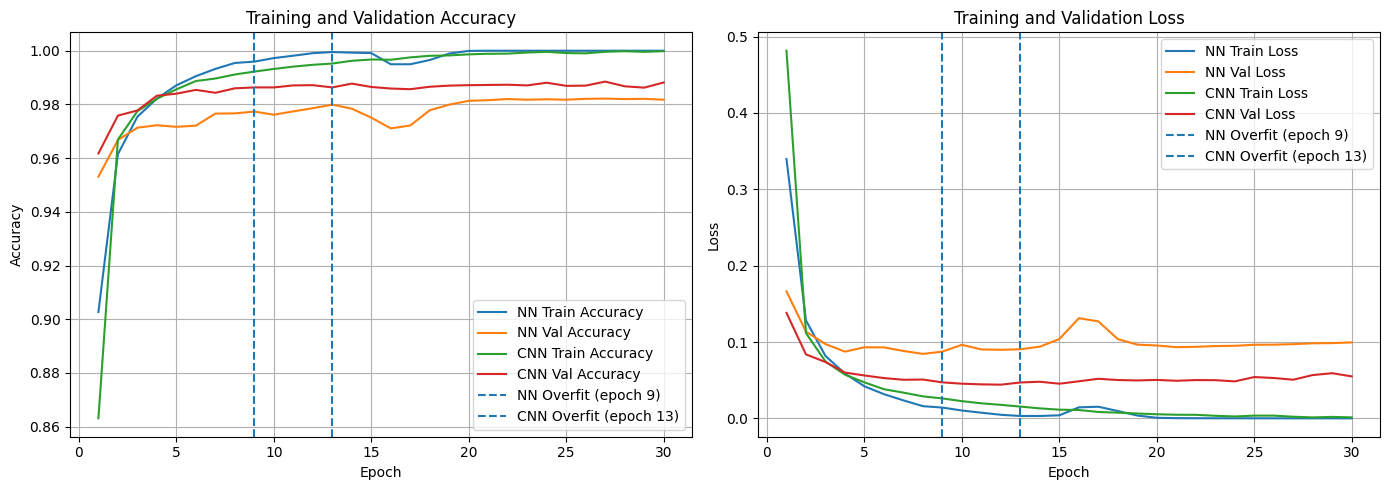

Saved combined figure as nn_vs_cnn_training_curves.png


In [ ]:
compare_training_curves_with_overfit(
    history_nn,
    history_cnn,
    filename="nn_vs_cnn_training_curves.png"
)


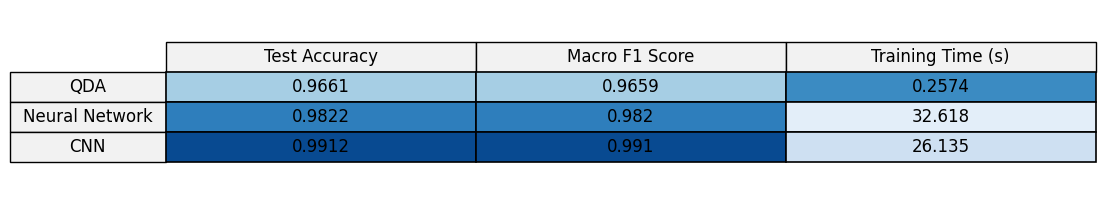

Saved as comparison_table_soft_blues.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

df = pd.DataFrame({
    'RowLabel': ['QDA', 'Neural Network', 'CNN'],
    'Test Accuracy': [0.9661, 0.9822, 0.9912],
    'Macro F1 Score': [0.9659, 0.9820, 0.9910],
    'Training Time (s)': [0.2574, 32.6180, 26.1350]
})

# Normalise per column (axis=0 like pandas Styler)

acc_vals = df['Test Accuracy'].values
f1_vals  = df['Macro F1 Score'].values
time_vals = df['Training Time (s)'].values

acc_norm = (acc_vals - acc_vals.min()) / (acc_vals.max() - acc_vals.min())
f1_norm  = (f1_vals  - f1_vals.min())  / (f1_vals.max()  - f1_vals.min())
time_norm = (time_vals - time_vals.min()) / (time_vals.max() - time_vals.min())

# Colourmaps
base_blues   = mpl.colormaps['Blues']
base_blues_r = mpl.colormaps['Blues_r']

def soft_blue(x):
    return base_blues(0.35 + 0.55 * x)

def soft_blue_r(x):
    return base_blues_r(0.35 + 0.55 * x)

# Create figure and table

fig, ax = plt.subplots(figsize=(10, 2.4))
ax.axis('off')

cell_data = df[['Test Accuracy', 'Macro F1 Score', 'Training Time (s)']].round(4).values

table = ax.table(
    cellText=cell_data,
    colLabels=['Test Accuracy', 'Macro F1 Score', 'Training Time (s)'],
    rowLabels=df['RowLabel'],
    cellLoc='center',
    rowLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Apply gradients to body cells only

for (row, col), cell in table.get_celld().items():

    # Header row
    if row == 0:
        cell.set_facecolor("#f2f2f2")
        cell.set_text_props(weight='normal')
        cell.set_edgecolor("black")
        continue

    # Row label column
    if col == -1:
        cell.set_facecolor("#f2f2f2")
        cell.set_edgecolor("black")
        continue

    # Body cells
    r_idx = row - 1  # align to df index

    if col == 0:
        cell.set_facecolor(soft_blue(acc_norm[r_idx]))
    elif col == 1:
        cell.set_facecolor(soft_blue(f1_norm[r_idx]))
    elif col == 2:
        cell.set_facecolor(soft_blue_r(time_norm[r_idx]))

    cell.set_edgecolor("black")
    cell.set_linewidth(1.2)

# Save and Show

plt.savefig("comparison_table_soft_blues.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved as comparison_table_soft_blues.png")


5. Final Analysis

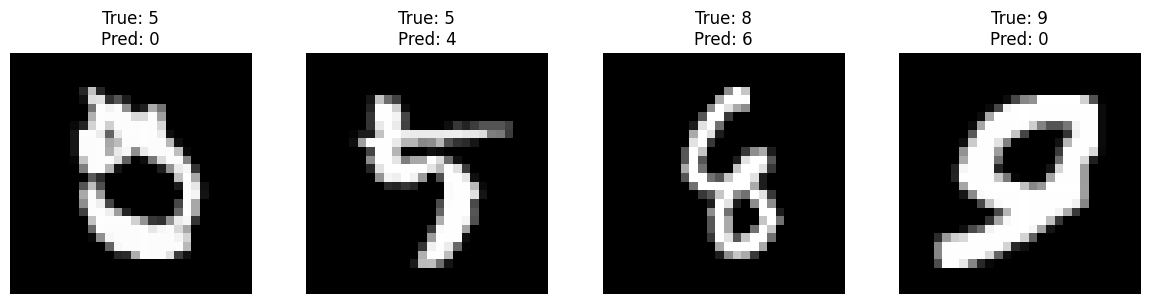

Saved as figure4_nn_wrong_examples.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_4_wrong_examples_nn(model_nn, X_test, y_test, seed=42, save_as="figure4_nn_wrong_examples.png"):
    # Predict probabilities and classes
    y_prob = model_nn.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Find misclassified indices
    wrong_idx = np.where(y_pred != y_test)[0]

    if len(wrong_idx) == 0:
        print("No misclassifications found!")
        return

    # Selection of 4 wrong examples
    rng = np.random.default_rng(seed)
    chosen = rng.choice(wrong_idx, size=min(4, len(wrong_idx)), replace=False)

    # Create 1x4 plot
    fig, axes = plt.subplots(1, len(chosen), figsize=(12, 3))
    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        img = X_test[idx]
        ax.imshow(img.reshape(28, 28), cmap='gray')
        ax.set_title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_as, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved as {save_as}")


plot_4_wrong_examples_nn(model_nn, X_test, y_test)


In [ ]:
import time
from sklearn.metrics import accuracy_score, f1_score

# Create CNN model
model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    # Second convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Third convolutional block
    #layers.Conv2D(64, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2)),
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
print("Model created!")
model.summary()

# Compile model
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
print("Model compiled!")

start_time = time.time()

# Train model
history = model.fit(
X_train_cnn, y_train_cnn,
epochs=15,
validation_split=0.2,
batch_size=256,
verbose=1
)
print("\nTraining complete!")

training_time = time.time() - start_time
print(f"Training time: {training_time:.3f} seconds")

Model created!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,482 (240.16 KB)

 Trainable params: 61,482 (240.16 KB)

 Non-trainable params: 0 (0.00 B)

Model compiled!
Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7426 - loss: 0.9248 - val_accuracy: 0.9645 - val_loss: 0.1222
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9663 - loss: 0.1161 - val_accuracy: 0.9765 - val_loss: 0.0816
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9768 - loss: 0.0760 - val_accuracy: 0.9807 - val_loss: 0.0645
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9820 - loss: 0.0592 - val_accuracy: 0.9815 - val_loss: 0.0648
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9842 - loss: 0.0498 - val_accuracy: 0.9815 - val_loss: 0.0607
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9876 - loss: 0.0414 - val_accuracy: 0.9839 - val_loss: 0.0535
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9894 - loss: 0.0361 - val_accuracy: 0.9870 - val_loss: 0.0470
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9908 - loss: 0.0310 -

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_cnn, verbose=1)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

y_pred_prob = model.predict(X_test_cnn, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
macro_f1 = f1_score(y_test_cnn, y_pred, average='macro')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9875 - loss: 0.0416
Test accuracy: 0.9902
Test loss: 0.0345
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
